# Postprocess downloaded MODIS data

MODIS provides satellite image data including ET, LAI and etc. Download data using [web UI](https://lpdaacsvc.cr.usgs.gov/appeears/task/area).

In [1]:

import xarray as xr
import rioxarray
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

import h5py as h5

import geopandas as gpd
from shapely.geometry import mapping
import netCDF4 as nc
from datetime import datetime, timedelta

In [2]:
name = 'Neches' # name the domain, used in filenames, etc
# Download the data on https://appeears.earthdatacloud.nasa.gov
# Note this data was downloaded using the shapefile Neches_full_domain.shp that must be in geographic coordinates.
# The data is provided in ESS-DIVE
fname_lai = '../data-raw/MODIS/Neches_MCD15A3H.061_500m_aid0001.nc'
fname_landcover = '../data-raw/MODIS/Neches_MCD12Q1.061_500m_aid0001.nc'
fname_watershed_shp = '../data-processed/basin/Neches_full_domain.shp' # This is WGS84


In [3]:
watershed_shape = gpd.read_file(fname_watershed_shp)
bounds = watershed_shape.bounds

# LAI

In [4]:
dset = xr.open_dataset(fname_lai)

In [5]:
data = dset.Lai_500m

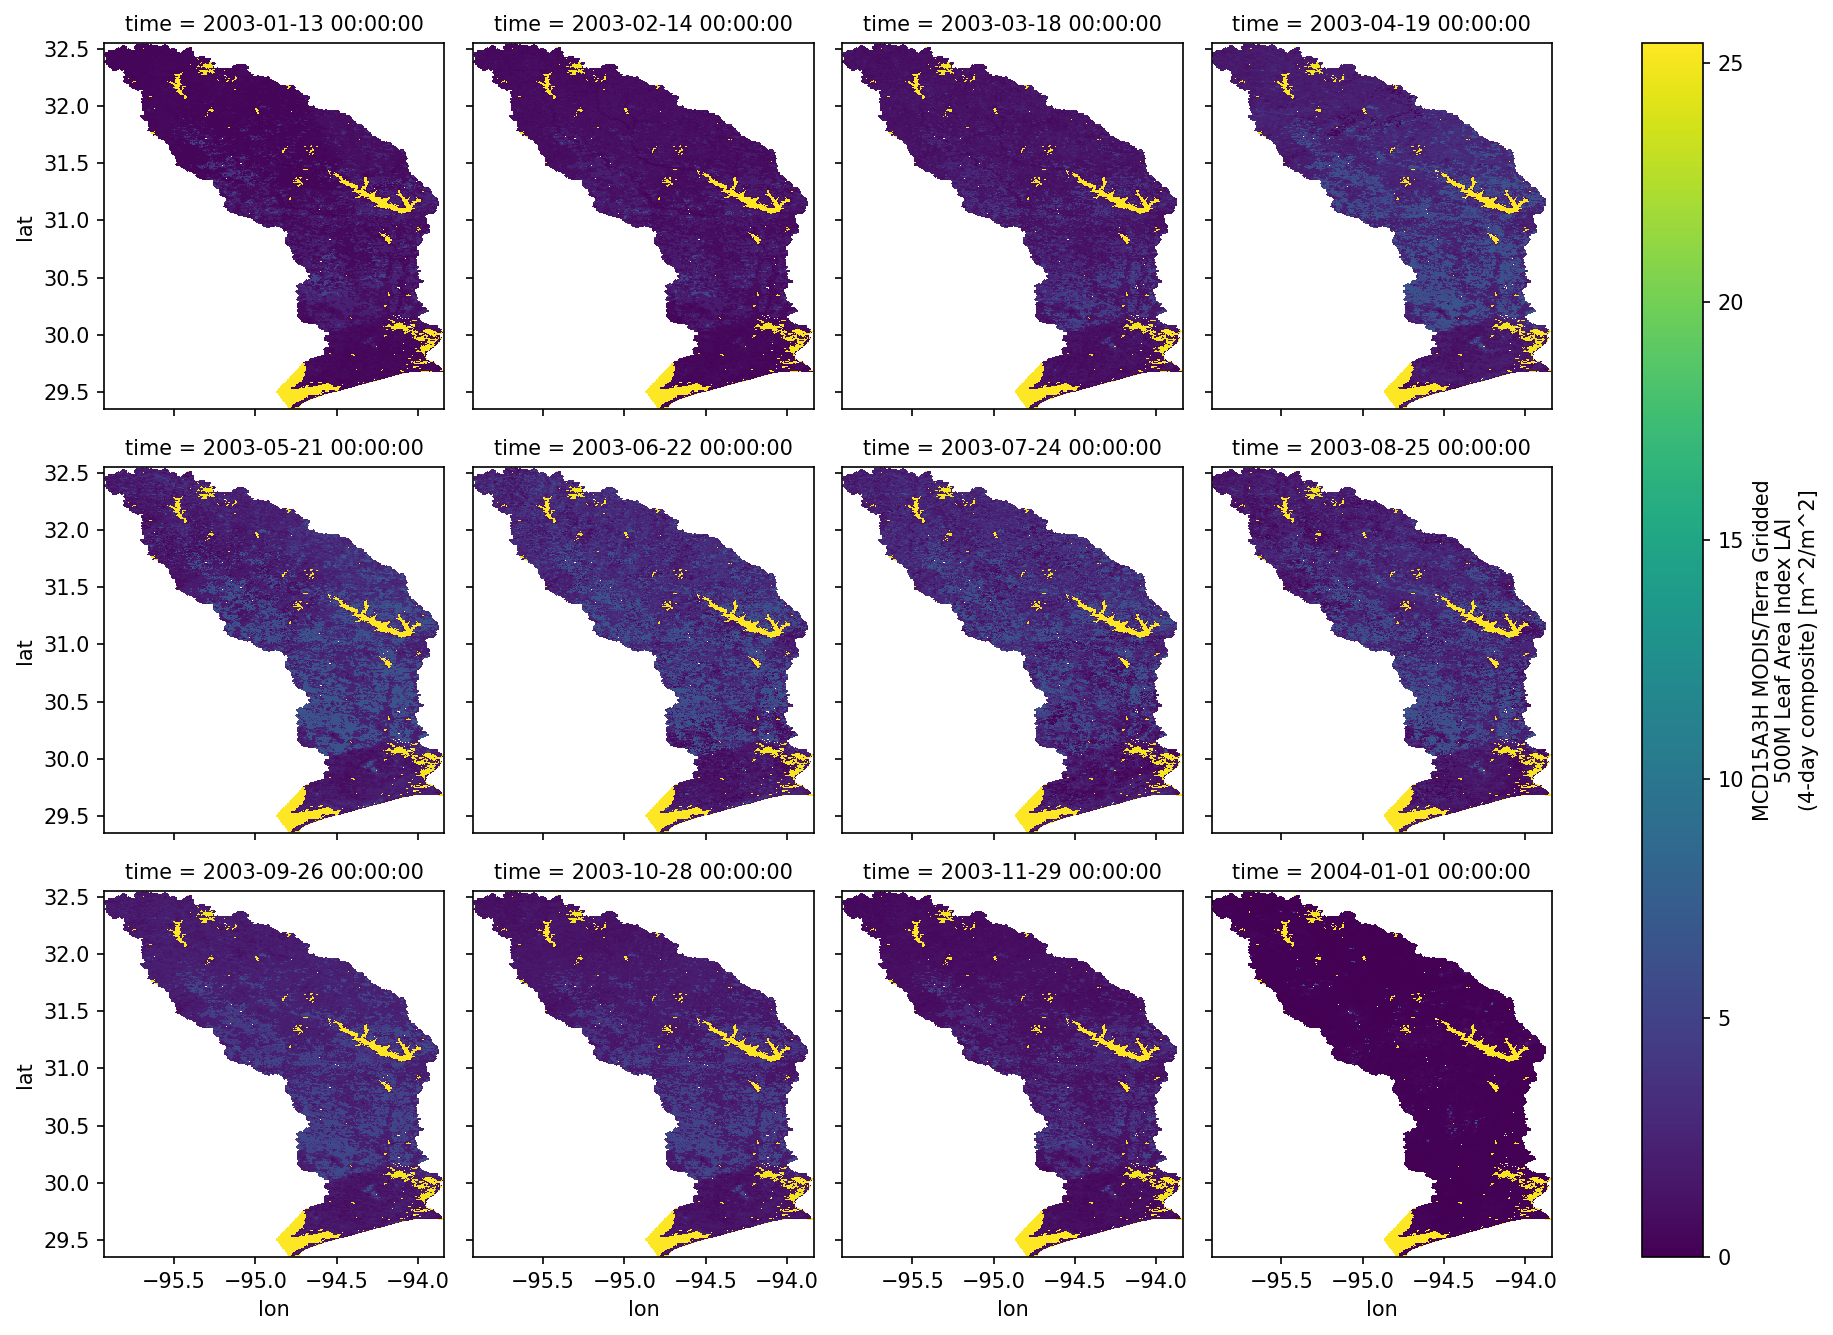

In [6]:
# iET = data.isel(time = slice(0, 90, 6))
g = data.isel(time = slice(48, 137, 8)).plot(x="lon", y='lat', col="time", col_wrap=4, robust = True,
        cmap = 'viridis',)

## mask data

Mask outliers in LAI

In [7]:
mask_data = data.where((data <= 10) & (data >= 0))

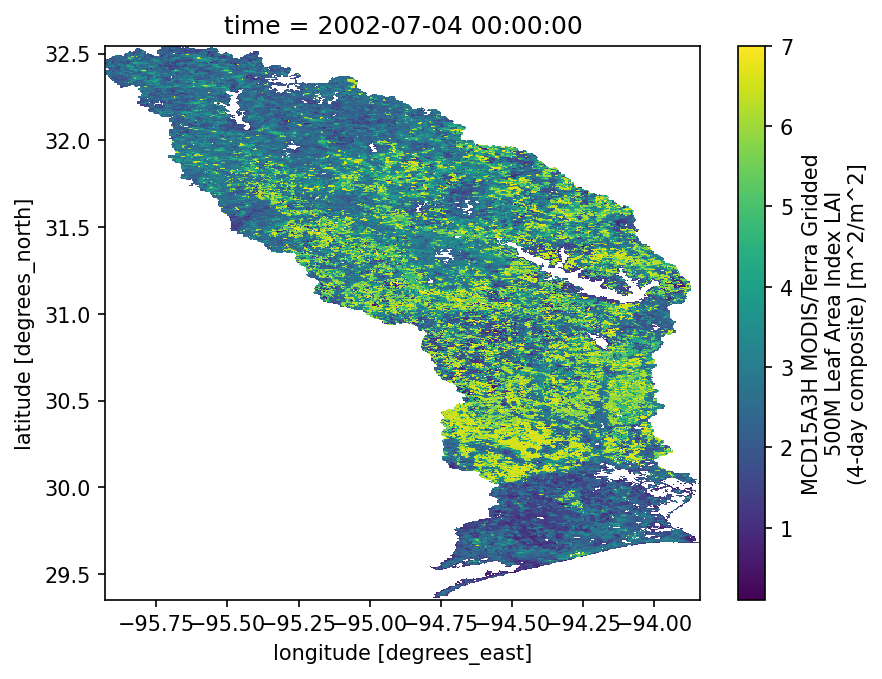

In [8]:
mask_data.isel(time = 0).plot()

## subset data

In [9]:
mask_data.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
mask_data.rio.write_crs("epsg:4326", inplace=True)
clipped_data = mask_data.rio.clip(watershed_shape.geometry.apply(mapping), watershed_shape.crs, drop = True)

In [10]:
CC_LAI = clipped_data

(29.350478755483884, 32.54232996198784)

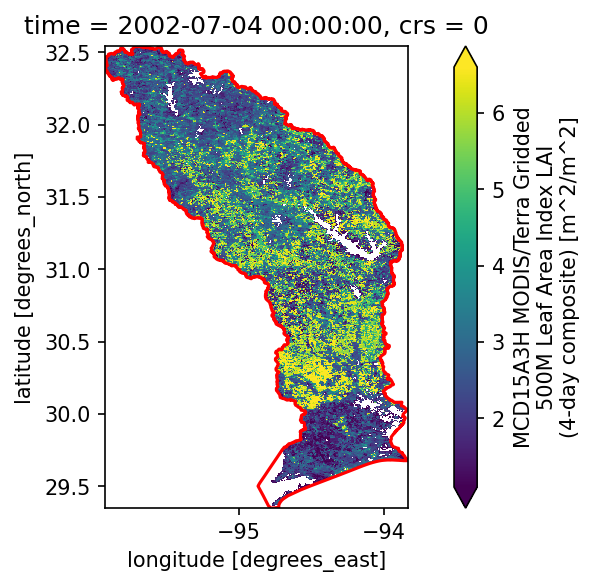

In [11]:
fig, ax = plt.subplots(1,1, figsize=(8,4))
clipped_data.isel(time = 0).plot( robust = True, ax=ax)
watershed_shape.boundary.plot(ax=ax, color ='r')
ax.set_aspect('equal')
ax.set_xlim([bounds['minx'].values[0], bounds['maxx'].values[0]])
ax.set_ylim([bounds['miny'].values[0], bounds['maxy'].values[0]])

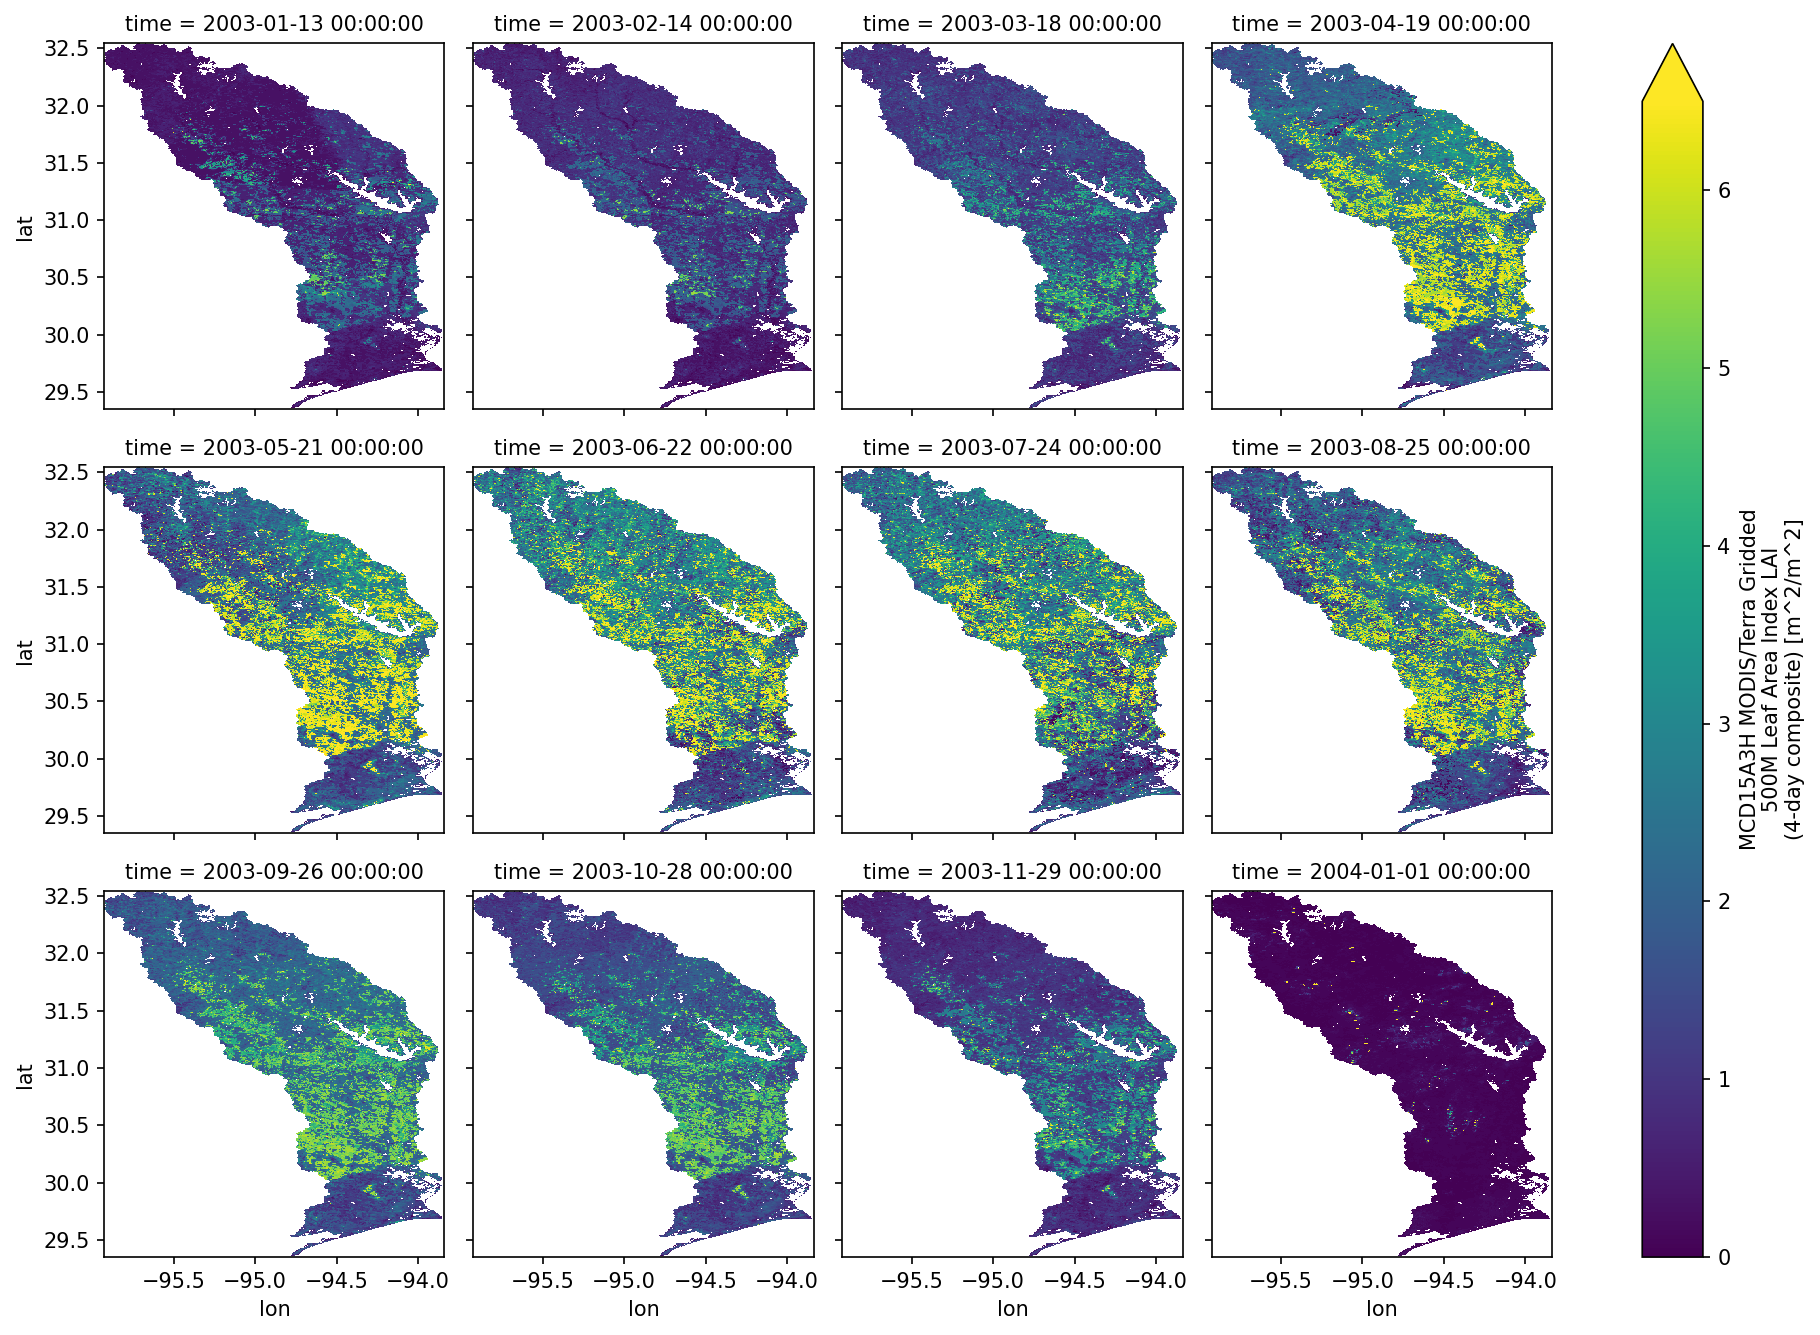

In [12]:
clipped_data.isel(time = slice(48, 137, 8)).plot(x="lon", y='lat', col="time", col_wrap=4, robust = True,
        cmap = 'viridis',)

# Landcover

In [13]:
dset = xr.open_dataset(fname_landcover)

In [14]:
dset

<xarray.Dataset>
Dimensions:   (time: 22, lat: 767, lon: 502)
Coordinates:
  * time      (time) object 2001-01-01 00:00:00 ... 2022-01-01 00:00:00
  * lat       (lat) float64 32.54 32.54 32.54 32.53 ... 29.36 29.36 29.36 29.35
  * lon       (lon) float64 -95.93 -95.92 -95.92 -95.91 ... -93.85 -93.84 -93.84
Data variables:
    crs       int8 ...
    LC_Type1  (time, lat, lon) float32 ...
    QC        (time, lat, lon) float32 ...
Attributes:
    title:        MCD12Q1.061 for aid0001
    Conventions:  CF-1.6
    institution:  Land Processes Distributed Active Archive Center (LP DAAC)
    source:       AppEEARS v3.49
    references:   See README.md
    history:      See README.md

In [15]:
# data = dset.LC_Type3
data = dset.LC_Type1

In [16]:
ids, counts = np.unique(data.values[~np.isnan(data.values)], return_counts=True)
ids, counts

(array([ 1.,  2.,  4.,  5.,  7.,  8.,  9., 10., 11., 12., 13., 14., 16.,
        17.], dtype=float32),
 array([  64923,  353715,  126960,  401404,       1, 1471542,  764632,
         176315,   50073,   11746,   50192,   48731,     440,  128224]))

In [17]:
lc_type1_colors = {
        -1:  ('None', (0.00000000000,  0.00000000000,  0.00000000000)),
        0: ('Open Water', (0.27843137255,  0.41960784314,  0.62745098039)),
        1: ('Evergreen Forest1', (0.10980392157,  0.38823529412,  0.18823529412)),
        2: ('Evergreen Forest2', (0.10980392157,  0.38823529412,  0.18823529412)),
        3: ('Deciduous Forest', (0.40784313726,  0.66666666667,  0.38823529412)),
        4: ('Deciduous Forest', (0.40784313726,  0.66666666667,  0.38823529412)),
        5: ('Mixed Forest', (0.70980392157,  0.78823529412,  0.55686274510)),
        6: ('Shrub/Scrub', (0.80000000000,  0.72941176471,  0.48627450980)),
        7: ('Shrub/Scrub', (0.80000000000,  0.72941176471,  0.48627450980)),
        8: ('Woody_Savannas', (0.40784313726,  0.66666666667,  0.38823529412)),
        9: ('Savannas', (0.70980392157,  0.78823529412,  0.55686274510)),
        10: ('Grassland', (0.80000000000,  0.72941176471,  0.48627450980)),
        11: ('Emergent Herbaceous Wetlands', (0.43921568628,  0.63921568628,  0.72941176471)),
        12: ('Cultivated Crops', (0.66666666667,  0.43921568628,  0.15686274510)),
        13: ('Developed, Open Space', (0.86666666667,  0.78823529412,  0.78823529412)),
        14: ('Cultivated Crops', (0.66666666667,  0.43921568628,  0.15686274510)),
        15: ('Perrenial Ice/Snow', (0.81960784314,  0.86666666667,  0.97647058824)),
        16: ('Barren Land', (0.69803921569,  0.67843137255,  0.63921568628)),
        17: ('Open Water', (0.27843137255,  0.41960784314,  0.62745098039)),
    } 

In [18]:
lc_colors = lc_type1_colors

In [19]:
colors = [lc_colors[i][1] for i in ids]

In [20]:
A = data.isel(time = -1)


In [21]:
# find the number of time sthat 16 is in A
np.sum(A.values == 16)

9

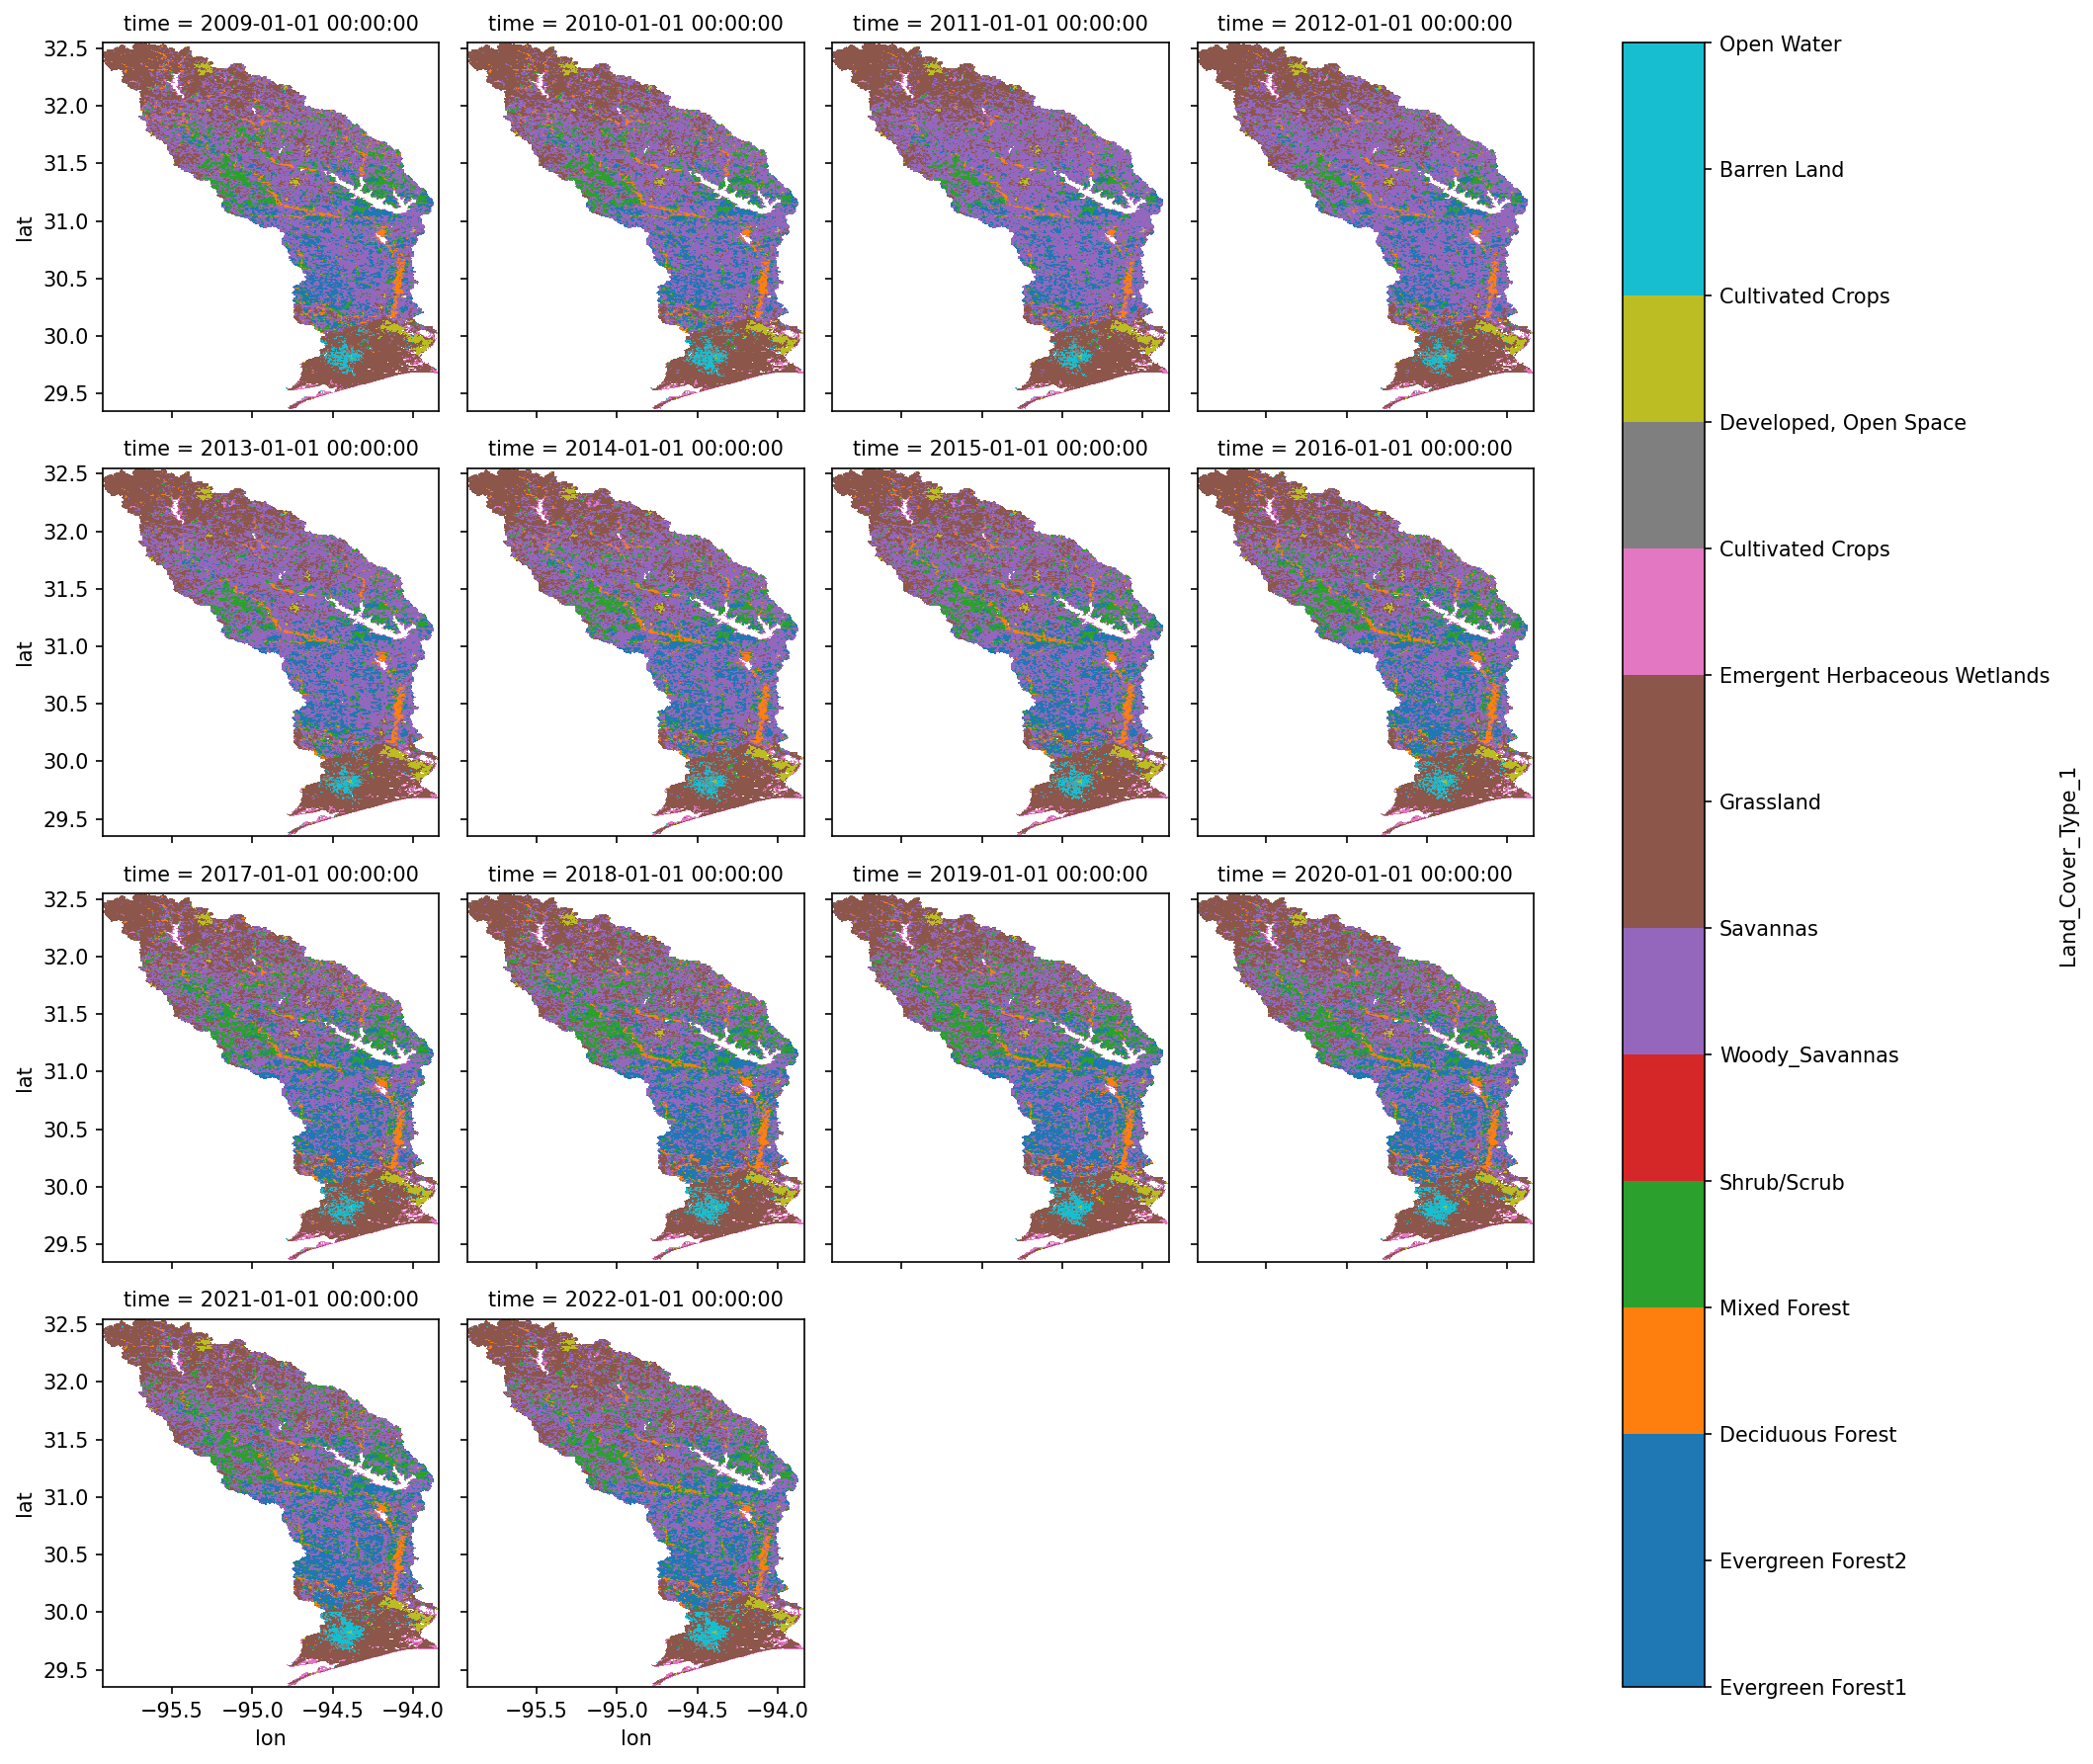

In [22]:
g = data.isel(time = slice(8, None, 1)).plot(x="lon", y='lat', col="time", col_wrap=4, 
                                             robust = True, levels=ids, cmap = 'tab10')     


g.cbar.set_ticks(ids)
g.cbar.set_ticklabels([lc_colors[i][0] for i in ids])
                                      

## subset data

In [23]:
mask_data = data

In [24]:
mask_data.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
mask_data.rio.write_crs("epsg:4326", inplace=True)
clipped_data = mask_data.rio.clip(watershed_shape.geometry.apply(mapping), watershed_shape.crs, drop = True)

In [25]:
CC_landcover = clipped_data

In [26]:
ids, counts = np.unique(clipped_data.values[~np.isnan(clipped_data.values)], return_counts=True)
ids, counts

colors = [lc_colors[i][1] for i in ids]

labels = [lc_colors[i][0] for i in ids]

In [27]:
ids = [0] + ids.tolist() + [11]

colors = ['grey'] + colors + ['k']
labels = ['None'] + labels + ['']

(29.350478755483884, 32.54232996198784)

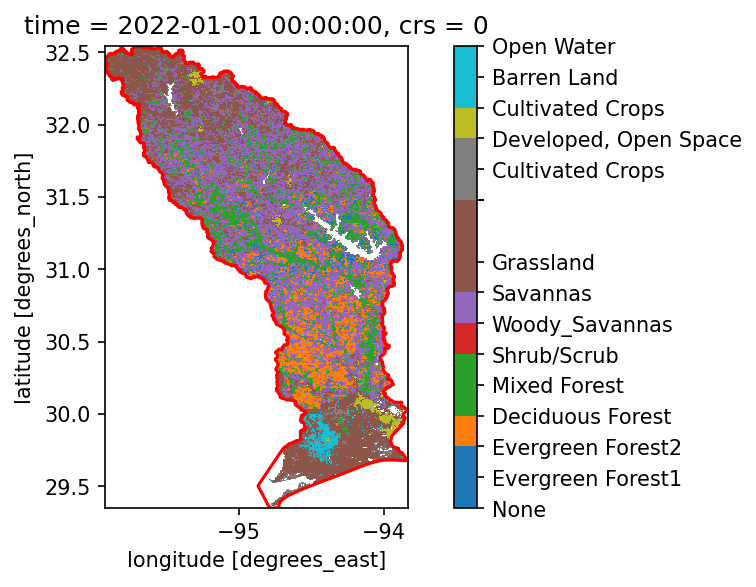

In [28]:
fig, ax = plt.subplots(1,1, figsize=(8,4))
# g = clipped_data.isel(time = -1).plot(  levels=ids, colors = colors, ax=ax, add_colorbar = False)
g = clipped_data.isel(time = -1).plot(  levels=ids, cmap = 'tab10', ax=ax, add_colorbar = False)

cb = plt.colorbar(g)
cb.set_ticks(ids)
cb.set_ticklabels(labels)

watershed_shape.boundary.plot(ax=ax, color ='r')
ax.set_aspect('equal')
ax.set_xlim([bounds['minx'].values[0], bounds['maxx'].values[0]])
ax.set_ylim([bounds['miny'].values[0], bounds['maxy'].values[0]])

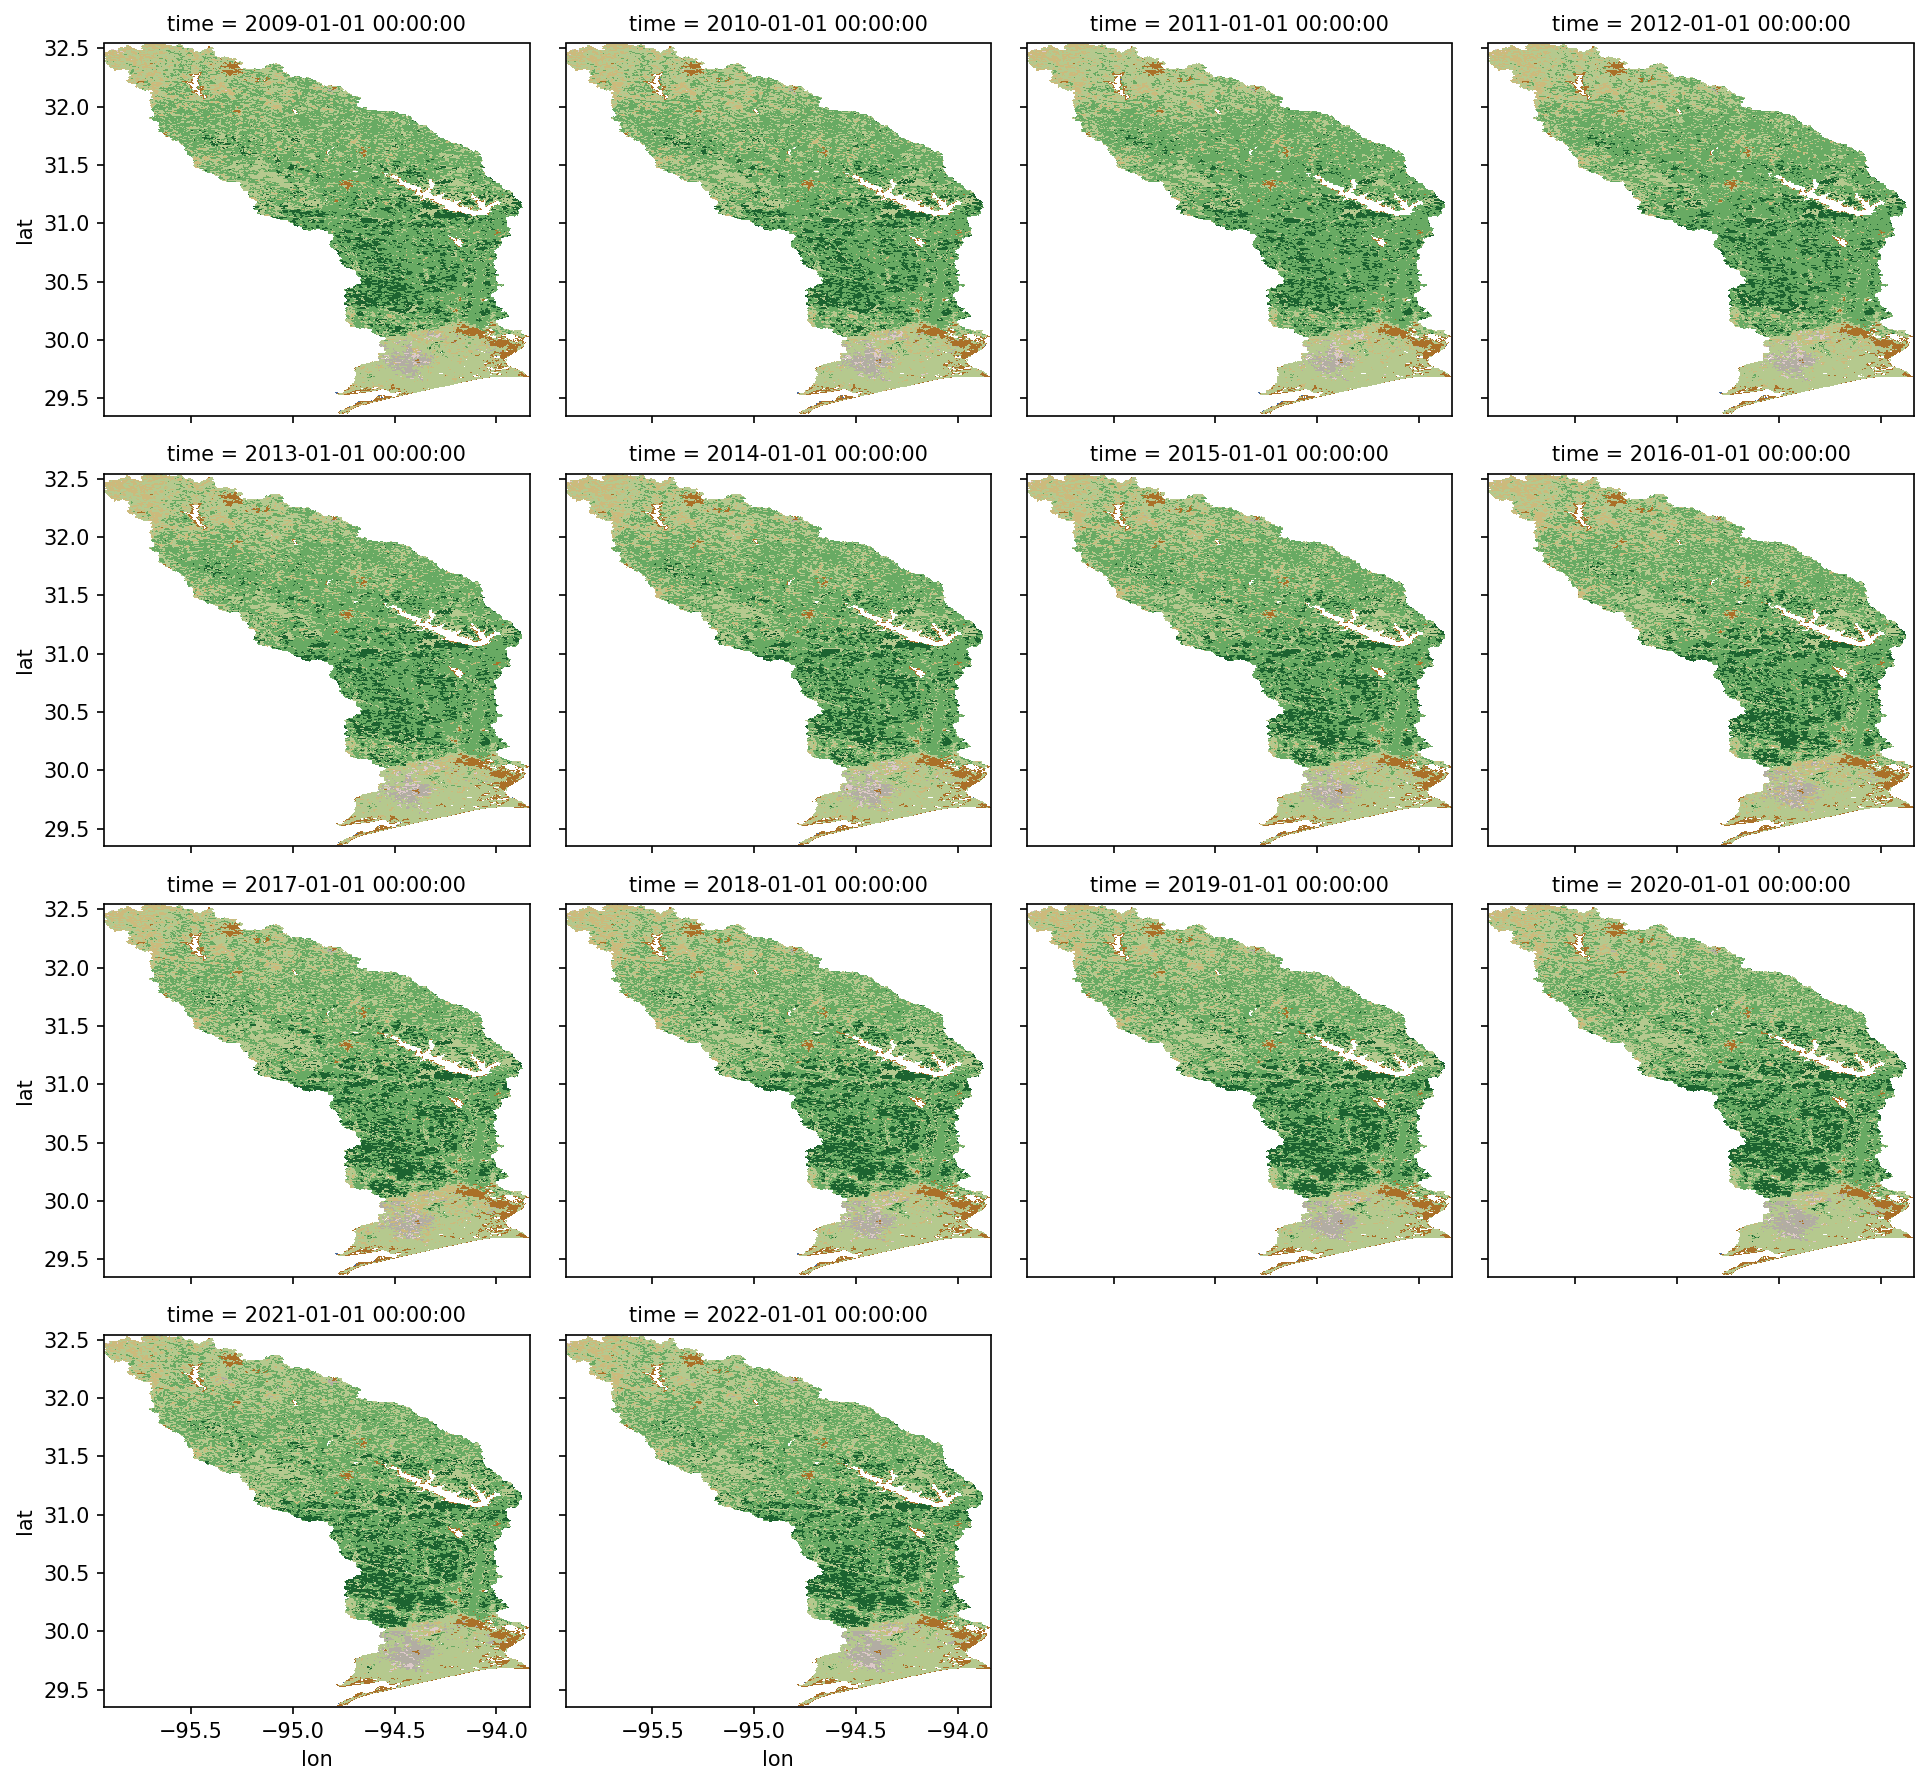

In [29]:
g = clipped_data.isel(time = slice(8, None, 1)).plot(x="lon", y='lat', col="time", col_wrap=4, 
                                                     levels=ids, colors = colors, add_colorbar = False,
                                            )

## extract LAI based on landcover types

In [30]:
ilandcover = CC_landcover.sel(time= "2019-01-01").values[0,:,:]

# ilandcover.shape
lc_ids = np.unique(CC_landcover.values[~np.isnan(CC_landcover.values)])
lc_labels = [lc_colors[i][0] for i in lc_ids]
times = CC_LAI.time.values

In [31]:
LAI_lc = []

for itime in times:
#     itime = times[0]
    iCC_LAI = CC_LAI.sel(time= itime).values

    iLAI_lc = []
    for i,ilabel in zip(lc_ids, lc_labels):
        idx = np.where(ilandcover == i)
        coords = list(zip(idx[0], idx[1]))
        # choose mean of the LAI for each landcover type
        iLAI = np.nanmean(np.array([iCC_LAI[i] for i in coords]))

        iLAI_lc.append(iLAI)
    
    LAI_lc.append(iLAI_lc)

/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_3244/2884007985.py:12: RuntimeWarning: Mean of empty slice
  iLAI = np.nanmean(np.array([iCC_LAI[i] for i in coords]))


In [32]:
LAI_lc = np.array(LAI_lc)

In [33]:
LAI_df = pd.DataFrame(LAI_lc, columns= lc_labels)
LAI_df['datetime'] = CC_LAI.indexes['time'].to_datetimeindex()
LAI_df.set_index('datetime', inplace=True)

/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_3244/645095651.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'julian', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  LAI_df['datetime'] = CC_LAI.indexes['time'].to_datetimeindex()


In [34]:
LAI_df

,Evergreen Forest1,Evergreen Forest2,Deciduous Forest,Mixed Forest,Shrub/Scrub,Woody_Savannas,Savannas,Grassland,Emergent Herbaceous Wetlands,Cultivated Crops,"Developed, Open Space",Cultivated Crops,Barren Land,Open Water
datetime,,,,,,,,,,,,,,
2002-07-04,3.770943,4.425056,4.784004,4.539751,NaN,3.520700,2.497691,2.257595,1.658484,1.753868,1.376044,1.692533,NaN,0.471429
2002-07-08,4.326812,4.353583,4.988515,4.943641,NaN,4.065771,2.884382,2.553642,1.685101,1.595580,1.328571,1.777395,NaN,0.971429
2002-07-12,2.576331,3.397301,3.949167,3.413576,NaN,2.362693,1.687858,1.457061,1.588865,1.551657,0.796923,1.495820,NaN,2.214286
2002-07-16,4.052149,4.379609,4.464591,4.321735,NaN,3.360481,2.235777,1.674895,1.712513,1.656630,1.363297,1.790544,NaN,0.657143
2002-07-20,4.149936,4.659349,5.150191,4.821735,NaN,3.558679,2.596296,2.284238,1.988494,1.771271,1.352967,1.765422,NaN,0.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-01,2.053624,2.112192,1.184647,2.003588,NaN,1.552724,1.085947,1.029973,0.354989,0.749171,0.570549,0.906412,NaN,0.114286
2024-03-05,1.850224,1.905471,1.239872,1.764005,NaN,1.409675,1.185625,1.134626,0.498726,0.820166,0.620000,1.017695,NaN,0.100000
2024-03-09,2.114240,2.116192,1.393121,2.119330,NaN,1.577779,1.201464,1.142189,0.596550,0.661050,0.534505,0.824797,NaN,0.171429


(11961.0, 13057.0)

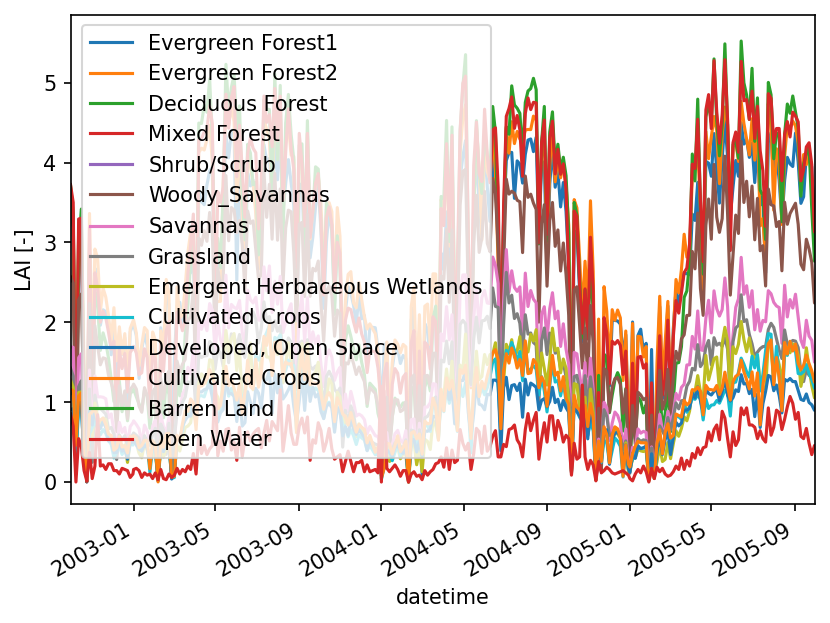

In [35]:
LAI_df.plot()
plt.ylabel('LAI [-]')
plt.xlim(["2002-10-01", "2005-10-01"])

## map MODIS landcover to NLCD landcover

Here we assume the following are interchangage. This is based on landcover map comparison between MODIS and NLCD. It maybe different depends on individual watershed.



In [ ]:
    # set the LAI time series for each NLCD class. We use the following mapping: This translation need to be done manually on the xml file!
    # NLCD Evergreen forest LAI [-] --> ['Evergreen Forest', 'Deciduous Forest','Dwarf Scrub', 'Shrub/Scrub', 'Grassland/Herbaceous', 'Sedge/Herbaceous', 
    #                      'Pasture/Hay', 'Cultivated Crops']
    # NLCD Deciduous forest LAI [-] --> ['Mixed Forest', 'Woody Wetlands','Emergent Herbaceous Wetlands']
    # NLCD Developed LAI [-] --> ['Developed, Open Space', 'Developed, Low Intensity', 'Developed, Medium Intensity', 'Developed, High Intensity',]
    # 0 --> ['Open Water', 'Perennial Ice/Snow','Barren Land',  'Lichens', 'Moss'] 
    # 0 --> All the Open Channel classes
    # Note that these mapping is based on the correlation found during the function "watershed_workflow.land_cover_properties.compute_crosswalk_correlation"

In [45]:
LAI_df.head()

,Evergreen Forest1,Evergreen Forest2,Deciduous Forest,Mixed Forest,Shrub/Scrub,Woody_Savannas,Savannas,Grassland,Emergent Herbaceous Wetlands,Cultivated Crops,"Developed, Open Space",Cultivated Crops,Barren Land,Open Water
datetime,,,,,,,,,,,,,,
2002-07-04,3.770943,4.425056,4.784004,4.539751,NaN,3.520700,2.497691,2.257595,1.658484,1.753868,1.376044,1.692533,NaN,0.471429
2002-07-08,4.326812,4.353583,4.988515,4.943641,NaN,4.065771,2.884382,2.553642,1.685101,1.595580,1.328571,1.777395,NaN,0.971429
2002-07-12,2.576331,3.397301,3.949167,3.413576,NaN,2.362693,1.687858,1.457061,1.588865,1.551657,0.796923,1.495820,NaN,2.214286
2002-07-16,4.052149,4.379609,4.464591,4.321735,NaN,3.360481,2.235777,1.674895,1.712513,1.656630,1.363297,1.790544,NaN,0.657143
2002-07-20,4.149936,4.659349,5.150191,4.821735,NaN,3.558679,2.596296,2.284238,1.988494,1.771271,1.352967,1.765422,NaN,0.600000


In [71]:
# Set the LAI for each NLCD class. This is done by using the weights estimated from the function crosswalk = watershed_workflow.land_cover_properties.compute_crosswalk_correlation(modis['LULC'].profile, modis['LULC'].data[0,:,:], lc_profile, lc_raster)
# See notebook mesh_Neches
nlcd_LAI = LAI_df.copy()
# Remove all the columns 
nlcd_LAI.drop(LAI_df.columns, axis=1, inplace=True)

nlcd_LAI['NLCD Open Water LAI [-]'] = LAI_df['Open Water'].values
nlcd_LAI['NLCD Developed, Open Space LAI [-]'] = (0.29*LAI_df['Woody_Savannas'].values + 0.27*LAI_df['Savannas'].values + 0.1*LAI_df['Grassland'].values + 0.14*LAI_df['Developed, Open Space'].values)/(0.29+0.27+0.1+0.14)
nlcd_LAI['NLCD Developed, Low Intensity LAI [-]'] = (0.19*LAI_df['Woody_Savannas'].values + 0.29*LAI_df['Savannas'].values + 0.1*LAI_df['Grassland'].values + 0.29*LAI_df['Developed, Open Space'].values)/(0.19+0.29+0.1+0.29)
nlcd_LAI['NLCD Developed, Medium Intensity LAI [-]'] = (0.20*LAI_df['Savannas'].values + 0.57*LAI_df['Developed, Open Space'].values)/(0.20+0.57)
nlcd_LAI['NLCD Developed, High Intensity LAI [-]'] = (0.16*LAI_df['Savannas'].values + 0.67*LAI_df['Developed, Open Space'].values)/(0.16+0.67)
nlcd_LAI['NLCD Barren Land LAI [-]'] = (0.22*LAI_df['Woody_Savannas'].values + 0.24*LAI_df['Savannas'].values + 0.13*LAI_df['Developed, Open Space'].values + 0.16*LAI_df['Open Water'].values)/(0.22+0.24+0.13+0.16)
nlcd_LAI['NLCD Deciduous Forest LAI [-]'] = (0.12*LAI_df['Mixed Forest'].values + 0.40*LAI_df['Woody_Savannas'].values + 0.26*LAI_df['Savannas'].values)/(0.12+0.40+0.26)
nlcd_LAI['NLCD Evergreen Forest LAI [-]'] = (0.14*LAI_df['Evergreen Forest2'].values + 0.19*LAI_df['Mixed Forest'].values + 0.41*LAI_df['Woody_Savannas'].values + 0.13*LAI_df['Savannas'].values)/(0.14+0.19+0.41+0.13)
nlcd_LAI['NLCD Mixed Forest LAI [-]'] = (0.13*LAI_df['Mixed Forest'].values + 0.40*LAI_df['Woody_Savannas'].values + 0.25*LAI_df['Savannas'].values)/(0.13+0.40+0.25)
nlcd_LAI['NLCD Shrub_Scrub LAI [-]'] = (0.11*LAI_df['Evergreen Forest2'].values + 0.14*LAI_df['Mixed Forest'].values + 0.45*LAI_df['Woody_Savannas'].values + 0.15*LAI_df['Savannas'].values)/(0.11+0.14+0.45+0.15)
nlcd_LAI['NLCD Grassland_Herbaceous LAI [-]'] = (0.11*LAI_df['Mixed Forest'].values + 0.48*LAI_df['Woody_Savannas'].values + 0.17*LAI_df['Savannas'].values)/(0.11+0.48+0.17)
nlcd_LAI['NLCD Pasture_Hay LAI [-]'] = (0.25*LAI_df['Woody_Savannas'].values + 0.36*LAI_df['Savannas'].values + 0.23*LAI_df['Grassland'].values)/(0.25+0.36+0.23)
nlcd_LAI['NLCD Cultivated Crops LAI [-]'] = (0.34*LAI_df['Savannas'].values + 0.47*LAI_df['Grassland'].values)/(0.34+0.47)
nlcd_LAI['NLCD Woody Wetlands LAI [-]'] = (0.14*LAI_df['Mixed Forest'].values + 0.35*LAI_df['Woody_Savannas'].values + 0.20*LAI_df['Savannas'].values)/(0.14+0.35+0.20)
nlcd_LAI['NLCD Emergent Herbaceous Wetlands LAI [-]'] = (0.11*LAI_df['Woody_Savannas'].values + 0.44*LAI_df['Savannas'].values + 0.11*LAI_df['Emergent Herbaceous Wetlands'].values + 0.14*LAI_df['Open Water'].values)/(0.11+0.44+0.11+0.14)


# # These relations are based on the NLCD land cover types and the LAI values from the NLCD data for a given watershed!!
# nlcd_LAI = LAI_df.copy()
# # We are using only two NLCD land covers in ATS input file 
# nlcd_LAI['NLCD Evergreen forest LAI [-]'] = (LAI_df['Evergreen Forest1'].values + LAI_df['Evergreen Forest2'].values+ LAI_df['Woody_Savannas'].values)/3
# nlcd_LAI['NLCD Deciduous forest LAI [-]'] =  (LAI_df['Mixed Forest'].values + LAI_df['Deciduous Forest'].values)/2
# nlcd_LAI['NLCD Developed LAI [-]'] = LAI_df['Developed, Open Space'].values
# nlcd_LAI.drop('Open Water', axis=1, inplace=True)


(11961.0, 13057.0)

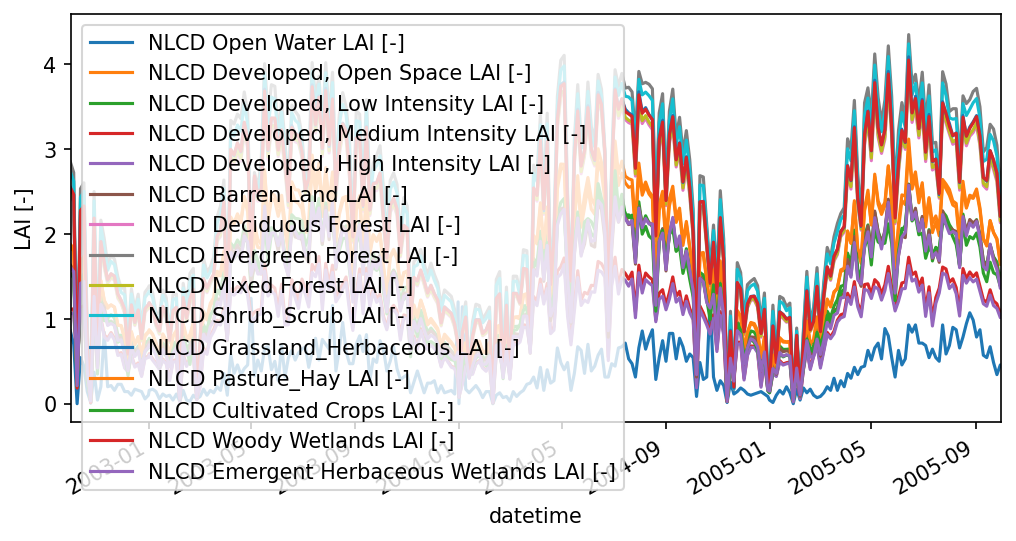

In [72]:
# Make a plot with all the NLCD LAI classes
fig, ax = plt.subplots(1,1, figsize=(8,4))
nlcd_LAI.plot(ax=ax)
ax.set_ylabel('LAI [-]')
ax.set_xlim(["2002-10-01", "2005-10-01"])

# nlcd_LAI.plot(y= ['NLCD Evergreen forest LAI [-]', 'NLCD Deciduous forest LAI [-]', 'NLCD Developed LAI [-]'], lw = 1)
# plt.ylabel("LAI [-]")
# plt.xlim(datetime(2002,10,1), datetime(2005,10,1))

### export to hdf5

In [38]:
# nlcd_LAI.dropna(inplace=True)

In [73]:
nlcd_LAI

,NLCD Open Water LAI [-],"NLCD Developed, Open Space LAI [-]","NLCD Developed, Low Intensity LAI [-]","NLCD Developed, Medium Intensity LAI [-]","NLCD Developed, High Intensity LAI [-]",NLCD Barren Land LAI [-],NLCD Deciduous Forest LAI [-],NLCD Evergreen Forest LAI [-],NLCD Mixed Forest LAI [-],NLCD Shrub_Scrub LAI [-],NLCD Grassland_Herbaceous LAI [-],NLCD Pasture_Hay LAI [-],NLCD Cultivated Crops LAI [-],NLCD Woody Wetlands LAI [-],NLCD Emergent Herbaceous Wetlands LAI [-]
datetime,,,,,,,,,,,,,,,
2002-07-04,0.471429,2.642231,2.319627,1.667381,1.592265,2.171085,3.336474,3.735916,3.362654,3.625047,3.439363,2.736417,2.358376,3.430940,2.168368
2002-07-08,0.971429,2.999026,2.585767,1.732678,1.628487,2.553152,3.807031,4.127275,3.833432,4.039127,3.928573,3.145426,2.692471,3.901458,2.547155
2002-07-12,2.214286,1.747722,1.511729,1.028335,0.968670,1.843685,2.299422,2.657847,2.321547,2.550582,2.363845,1.825507,1.553939,2.380311,1.859161
2002-07-16,0.657143,2.420688,2.126106,1.589915,1.531486,2.077685,3.133465,3.566349,3.160208,3.452215,3.248031,2.416936,1.910327,3.229517,2.042214
2002-07-20,0.600000,2.688570,2.356160,1.675910,1.592645,2.237208,3.432201,3.867834,3.460732,3.739319,3.526220,2.797275,2.415225,3.536000,2.295699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-01,0.114286,1.157962,1.009654,0.704419,0.669903,0.926245,1.466495,1.671470,1.478260,1.617013,1.513570,1.209543,1.053468,1.508906,0.879581
2024-03-05,0.100000,1.161484,1.040152,0.766916,0.729036,0.921705,1.389504,1.533362,1.396919,1.492659,1.410843,1.238342,1.156033,1.416626,0.931999
2024-03-09,0.171429,1.213751,1.054515,0.707741,0.663076,0.976503,1.535656,1.726459,1.547424,1.670244,1.571986,1.297232,1.167070,1.578582,0.989775


In [74]:
nlcd_LAI['time [s]'] = (nlcd_LAI.index - nlcd_LAI.index[0]).total_seconds()

In [76]:
with h5.File('../data-processed/' + name + '_MODIS_LAI_072002_122020.h5', 'w') as fout:
   
    Name_NLCD_classes = nlcd_LAI.columns.tolist() # this include the time vector as well
    for i in Name_NLCD_classes:
        fout.create_dataset(i, data= nlcd_LAI[i].values)
        